<a href="https://colab.research.google.com/github/ruilili3-cell/cs5494_tutorial/blob/main/cs5494_tutorial_3_tokenizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 3: Tokenization and Token Embeddings

A language model cannot operate directly on characters or strings. It needs a sequence of discrete symbols, represented by integer IDs, and then a sequence of continuous vectors.

In this tutorial, we will:

1. Build a simple tokenizer from scratch.
2. Examine the out-of-vocabulary problem.
3. Use a pretrained BERT tokenizer.
4. Connect token IDs to token embeddings.

## Setup and Data



In [ ]:
# Import the tools used for tokenization, tensor operations, and visualization.
import numpy as np
import re  # regex
import torch  # PyTorch / ML tool
from transformers import BertTokenizer  # load tokenizer
from transformers import BertModel
from collections import OrderedDict
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Project high-dimensional embedding vectors into 2D for visualization.
def plot_embedding_pca(embedding_vectors, labels=None):
    # Each label identifies one embedding vector in the plot.

    if labels is None:
        labels = range(len(embedding_vectors))
    reduced_vectors = PCA(n_components=2, random_state=42).fit_transform(
        embedding_vectors
    )

    # Draw each reduced vector from the origin.
    plt.figure(figsize=(10, 6))
    origin = np.zeros((len(embedding_vectors), 2))
    for i, label in enumerate(labels):
        plt.quiver(
            origin[:, 0],
            origin[:, 1],
            reduced_vectors[i, 0],
            reduced_vectors[i, 1],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.002,
        )
        plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
        plt.annotate(label, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

    plt.title("Embedding Visualization (using 2 Principal Components)")
    plt.show()


In [ ]:
# Load a short text sample for building and testing a toy tokenizer.
raw_text = '''
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)

"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it's going to send the value of my picture 'way up; but I don't think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing's lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn's "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?
'''

print("Total number of characters:", len(raw_text))
print(raw_text[:99])

Total number of characters: 978

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no


## 1. Tokenization


A tokenizer converts text into a sequence of tokens and maps each token to an integer ID in a vocabulary.

The basic workflow is:

**Text → Tokens → Token IDs**

### 1.1 Building a Tokenizer from Scratch

Let's build a simple tokenizer in which each word or punctuation mark corresponds to one token.

In [ ]:
# Apply a simple rule-based split to expose words, punctuation, and whitespace.
tokens = [item for item in re.split(r'([,.:;?_!"()\']|--|\s)', raw_text) if item]
print(raw_text[:57])
print(tokens[:20])


I HAD always thought Jack Gisburn rather a cheap genius-
['\n', 'I', ' ', 'HAD', ' ', 'always', ' ', 'thought', ' ', 'Jack', ' ', 'Gisburn', ' ', 'rather', ' ', 'a', ' ', 'cheap', ' ', 'genius']


In [ ]:
# Measure the sequence length and vocabulary size of the sample.
# How many tokens are there?
print("Number of tokens in text:", len(tokens))

# How many unique tokens are there?
unique_tokens = sorted(set(tokens))
print("Number of unique tokens:", len(unique_tokens))

Number of tokens in text: 405
Number of unique tokens: 138


### Inspect the Vocabulary

In [ ]:
# Build a vocabulary by assigning one integer ID to each unique token.
vocab = {token: integer for integer, token in enumerate(unique_tokens)}

# Show first entries
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('\n', 0)
(' ', 1)
('"', 2)
("'", 3)
('(', 4)
(')', 5)
(',', 6)
('--', 7)
('.', 8)
(':', 9)
(';', 10)
('?', 11)
('And', 12)
('Arrt', 13)
('Chicago', 14)
('Croft', 15)
('Florence', 16)
('Gallery', 17)
('Gideon', 18)
('Gisburn', 19)
('Grafton', 20)
('HAD', 21)
('Had', 22)
('Hermia', 23)
('I', 24)
('Jack', 25)
('Moon-dancers', 26)
('Mr', 27)
('Mrs', 28)
('Of', 29)
('Rickham', 30)
('Riviera', 31)
('Rome', 32)
('The', 33)
('Though', 34)
('Thwing', 35)
('Thwings', 36)
('We', 37)
('_', 38)
('a', 39)
('abdication', 40)
('again', 41)
('all', 42)
('always', 43)
('an', 44)
('and', 45)
('as', 46)
('at', 47)
('been', 48)
('before', 49)
('but', 50)


### Build a Reusable Tokenizer

In [ ]:
# Combine tokenization, encoding, and decoding in one reusable class.
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r"\1", text)
        return text

    # Expose the intermediate tokens before converting them to IDs.
    def tokenize(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        return preprocessed

### Test Encoding and Decoding

In [ ]:
# Run the complete text → tokens → IDs → text workflow.
tokenizer = SimpleTokenizerV1(vocab)

text = """"I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication."""
print("Original text:", text)
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)
ids = tokenizer.encode(text)
print("Token IDs:", ids)
reconstructed_text = tokenizer.decode(ids)
print("Reconstructed text:", reconstructed_text)

Original text: "I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication.
Tokens: ['"', 'I', 'can', 'hear', 'Mrs', '.', 'Gideon', 'Thwing', '--', 'his', 'last', 'Chicago', 'sitter', '--', 'deploring', 'his', 'unaccountable', 'abdication', '.']
Token IDs: [2, 24, 52, 72, 28, 8, 18, 35, 7, 76, 81, 14, 109, 7, 55, 76, 122, 40, 8]
Reconstructed text: " I can hear Mrs. Gideon Thwing -- his last Chicago sitter -- deploring his unaccountable abdication.


### The Out-of-Vocabulary Problem

What happens if we use new text that contains previously unseen words?

In [ ]:
# Test the tokenizer on words that do not appear in its vocabulary.
try:
    text = """BERT models are useful for many NLP tasks."""
    print("Original text:", text)
    tokens = tokenizer.tokenize(text)
    print("Tokens:", tokens)
    ids = tokenizer.encode(text)
    print("Token IDs:", ids)
    reconstructed_text = tokenizer.decode(ids)
    print("Reconstructed text:", reconstructed_text)
except Exception as e:
    print("Error:", e)

Original text: BERT models are useful for many NLP tasks.
Tokens: ['BERT', 'models', 'are', 'useful', 'for', 'many', 'NLP', 'tasks', '.']
Error: 'BERT'


#### A Simple Solution: the `<unk>` Token

In [ ]:
# Reserve the final vocabulary ID for all unknown tokens.
unknown_token = {"<unk>": len(vocab)}
vocab.update(unknown_token)

In [ ]:
# Extend the tokenizer so unseen words are mapped to <unk>.
class SimpleTokenizerV2:
    def __init__(self, vocab, unknown_token):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}
        self.unknown_token = unknown_token

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            s if s in self.str_to_int else list(self.unknown_token.keys())[0]
            for s in preprocessed
        ]  # Replace unseen words with the unknown token.
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r"\1", text)
        return text

    # Expose the intermediate tokens before converting them to IDs.
    def tokenize(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            s if s in self.str_to_int else list(self.unknown_token.keys())[0]
            for s in preprocessed
        ]  # Replace unseen words with the unknown token.
        return preprocessed

In [ ]:
# Verify that unseen words no longer cause an encoding error.

tokenizer = SimpleTokenizerV2(vocab, unknown_token)

# Out-of-vocabulary example
text = """I love LLMs because they know English better than me."""
print("Original text:", text)
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)
ids = tokenizer.encode(text)
print("Token IDs:", ids)
reconstructed_text = tokenizer.decode(ids)
print("Reconstructed text:", reconstructed_text)

Original text: I love LLMs because they know English better than me.
Tokens: ['I', '<unk>', '<unk>', '<unk>', 'they', '<unk>', '<unk>', '<unk>', '<unk>', 'me', '.']
Token IDs: [24, 138, 138, 138, 117, 138, 138, 138, 138, 87, 8]
Reconstructed text: I <unk> <unk> <unk> they <unk> <unk> <unk> <unk> me.


### 1.2 Using a Pretrained Tokenizer

Our simple tokenizer can only recognize tokens that appeared in its original vocabulary. Replacing every unseen word with `<unk>` causes information loss.

Pretrained language models therefore use more sophisticated tokenization methods. BERT uses **WordPiece**, which can split an unfamiliar word into smaller units called subwords.

We will now load the tokenizer associated with `bert-base-uncased`.

In [ ]:
# Load the WordPiece tokenizer that was trained with BERT.
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased", clean_up_tokenization_spaces=True
)
print("Size of Vocabulary:", len(tokenizer.vocab))
OrderedDict(list(tokenizer.vocab.items())[::1000])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Size of Vocabulary: 30522


OrderedDict([('discontent', 27648),
             ('[unused641]', 646),
             ('espana', 20678),
             ('worcester', 12539),
             ('subway', 10798),
             ('ᅲ', 1480),
             ('##ła', 22972),
             ('commanders', 11437),
             ('184', 19681),
             ('romeo', 12390),
             ('societe', 18341),
             ('serialized', 27289),
             ('slot', 10453),
             ('voted', 5444),
             ('bishopric', 20664),
             ('seton', 28796),
             ('apache', 15895),
             ('las', 5869),
             ('alderman', 18977),
             ('##rdial', 25070),
             ('mention', 5254),
             ('miserable', 13736),
             ('清', 1903),
             ('incomes', 29373),
             ('arrondissement', 20522),
             ('sparks', 12300),
             ('slalom', 19617),
             ('hellenistic', 27464),
             ('researching', 20059),
             ('##um', 2819),
             ('acre', 7

Use the pretrained tokenizer to **tokenize, encode, and decode** a new sentence.

In [ ]:
# Inspect both the subword tokens and their corresponding vocabulary IDs.
text = "Does Donald J. Trump have a better golf handicap than Biden?"
print("Original text:", text)
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)
ids = tokenizer.encode(text)  # Automatically adds special tokens at start and end
print("Token IDs:", ids)
reconstructed_text = tokenizer.decode(ids)
print("Reconstructed text:", reconstructed_text)

Original text: Does Donald J. Trump have a better golf handicap than Biden?
Tokens: ['does', 'donald', 'j', '.', 'trump', 'have', 'a', 'better', 'golf', 'handicap', 'than', 'bid', '##en', '?']
Token IDs: [101, 2515, 6221, 1046, 1012, 8398, 2031, 1037, 2488, 5439, 15822, 2084, 7226, 2368, 1029, 102]
Reconstructed text: [CLS] does donald j. trump have a better golf handicap than biden? [SEP]


Notice that `Biden` is split into `bid` and `##en`. The prefix `##` indicates that the subword continues the preceding token. The encoded sequence also contains BERT's special tokens `[CLS]` and `[SEP]`.

## 2. Token Embeddings

Token IDs are vocabulary indices; their numerical values do not carry meaning by themselves. An embedding layer maps each token ID to a trainable vector representation.

**Text → Tokens → Token IDs → Token Embeddings**

### 2.1 Randomly Initialized Embeddings

Initialize a token embedding layer using `torch.nn.Embedding`. This creates a trainable lookup table with one vector per vocabulary item.

In [ ]:
# Create a small embedding table for a toy vocabulary.
vocab_size = 100  # example
output_dim = 10  # example

torch.manual_seed(123)
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(token_embedding_layer.weight)

Parameter containing:
tensor([[ 3.3737e-01, -1.7778e-01, -3.0353e-01, -5.8801e-01,  3.4861e-01,
          6.6034e-01, -2.1964e-01, -3.7917e-01,  7.6711e-01, -1.1925e+00],
        [ 6.9835e-01, -1.4097e+00,  1.7938e-01,  1.8951e+00,  4.9545e-01,
          2.6920e-01, -7.7020e-02, -1.0205e+00, -1.6896e-01,  9.1776e-01],
        [ 1.5810e+00,  1.3010e+00,  1.2753e+00, -2.0095e-01,  4.9647e-01,
         -1.5723e+00,  9.6657e-01, -1.1481e+00, -1.1589e+00,  3.2547e-01],
        [-6.3151e-01, -2.8400e+00, -1.3250e+00,  1.7843e-01, -2.1338e+00,
          1.0524e+00, -3.8848e-01, -9.3435e-01, -4.9914e-01, -1.0867e+00],
        [ 8.8054e-01,  1.5542e+00,  6.2662e-01, -1.7549e-01,  9.8284e-02,
         -9.3507e-02,  2.6621e-01, -5.8504e-01,  8.7684e-01,  1.6221e+00],
        [-1.4779e+00,  1.1331e+00, -1.2203e+00,  1.3139e+00,  1.0533e+00,
          1.3881e-01,  2.2473e+00, -8.0364e-01, -2.8084e-01,  7.6968e-01],
        [-6.5956e-01, -7.9793e-01,  1.8383e-01,  2.2935e-01,  5.1463e-01,
          

### Look Up Embeddings for a Token Sequence

In [ ]:
# Use token IDs as row indices in the embedding table.
ids = torch.tensor([2, 3, 5, 1])
token_embedding = token_embedding_layer(ids)
print(token_embedding.shape)
print(token_embedding)

torch.Size([4, 10])
tensor([[ 1.5810,  1.3010,  1.2753, -0.2010,  0.4965, -1.5723,  0.9666, -1.1481,
         -1.1589,  0.3255],
        [-0.6315, -2.8400, -1.3250,  0.1784, -2.1338,  1.0524, -0.3885, -0.9343,
         -0.4991, -1.0867],
        [-1.4779,  1.1331, -1.2203,  1.3139,  1.0533,  0.1388,  2.2473, -0.8036,
         -0.2808,  0.7697],
        [ 0.6984, -1.4097,  0.1794,  1.8951,  0.4954,  0.2692, -0.0770, -1.0205,
         -0.1690,  0.9178]], grad_fn=<EmbeddingBackward0>)


Visualize the token embedding vectors using principal component analysis (PCA).

PCA projects the 10-dimensional vectors into two dimensions so that they can be displayed.

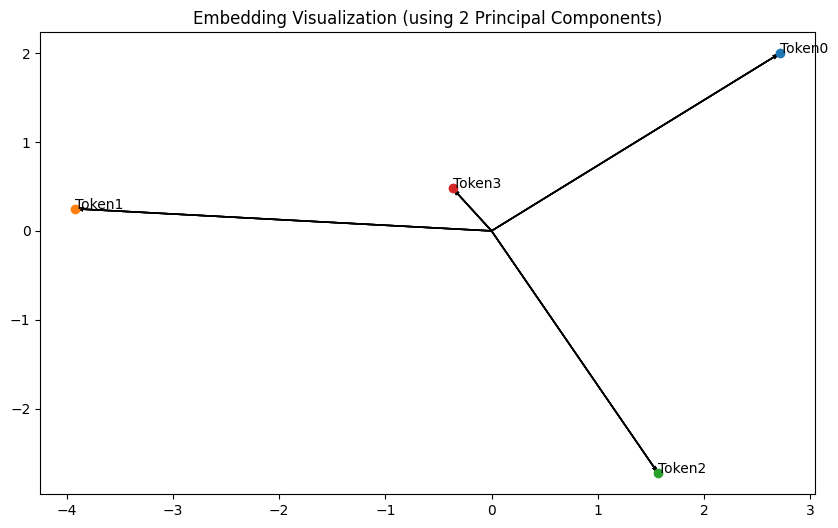

In [ ]:
# Convert the selected tensors to NumPy arrays for PCA and plotting.
token_embedding_vectors = [
    token_embedding[i].detach().numpy() for i in range(token_embedding.shape[0])
]
plot_embedding_pca(
    token_embedding_vectors,
    labels=[f"Token{i}" for i in range(len(token_embedding_vectors))],
)

These embeddings have no learned semantic structure because they are **randomly initialized and untrained**.

In an LLM, token embeddings are trained as part of the training process.
Next, we examine token embeddings learned during BERT pretraining.

### 2.2 Pretrained Embeddings

The tokenizer maps text to token IDs, and BERT's embedding layer maps those IDs to learned input vectors. We now load BERT's pretrained token embedding table.

In [ ]:
# Load BERT and access the embedding table shared by its vocabulary.
model = BertModel.from_pretrained("bert-base-uncased")

# Token embeddings
token_embedding = model.embeddings.word_embeddings.weight
print("Token Embeddings:", token_embedding.shape)
print("Token Embeddings:", token_embedding)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Token Embeddings: torch.Size([30522, 768])
Token Embeddings: Parameter containing:
tensor([[-0.0102, -0.0615, -0.0265,  ..., -0.0199, -0.0372, -0.0098],
        [-0.0117, -0.0600, -0.0323,  ..., -0.0168, -0.0401, -0.0107],
        [-0.0198, -0.0627, -0.0326,  ..., -0.0165, -0.0420, -0.0032],
        ...,
        [-0.0218, -0.0556, -0.0135,  ..., -0.0043, -0.0151, -0.0249],
        [-0.0462, -0.0565, -0.0019,  ...,  0.0157, -0.0139, -0.0095],
        [ 0.0015, -0.0821, -0.0160,  ..., -0.0081, -0.0475,  0.0753]],
       requires_grad=True)


Visualize the pretrained input embeddings of several selected words.

PCA projects the selected 768-dimensional vectors into two dimensions. This visualization is illustrative; the 2D distances do not represent BERT's full contextual meaning.

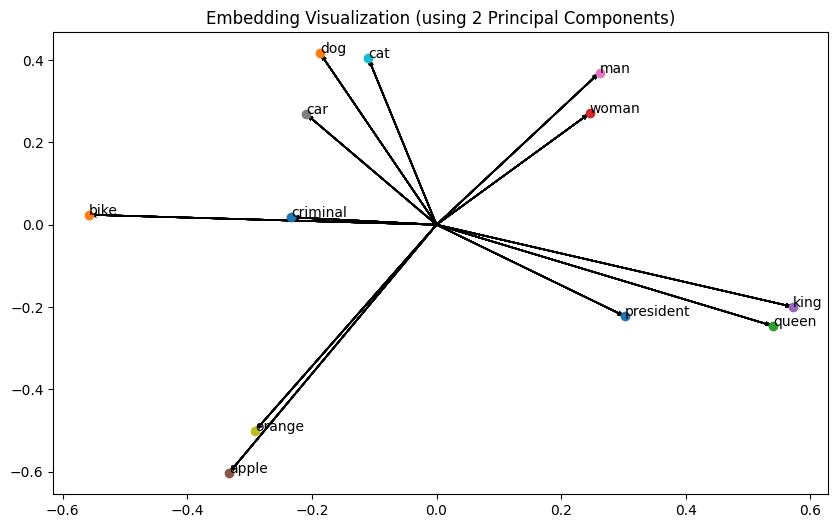

In [ ]:
# Select familiar words that occur as complete tokens in BERT's vocabulary.
words = [
    "king",
    "queen",
    "man",
    "woman",
    "dog",
    "cat",
    "apple",
    "orange",
    "car",
    "bike",
    "criminal",
    "president",
]

# Match each selected token with its vocabulary ID.
vocab_selected = {
    item[0]: item[1] for item in tokenizer.vocab.items() if item[0] in words
}

# Report any requested words that are absent from the vocabulary.
missing_tokens = set(words) - set(vocab_selected.keys())
if len(missing_tokens) > 0:
    print("Non-existing Tokens:", missing_tokens)

# Retrieve the corresponding pretrained embedding vectors.
token_embedding_vectors = [
    token_embedding[list(vocab_selected.values())][i].detach().numpy()
    for i in range(len(vocab_selected))
]

plot_embedding_pca(token_embedding_vectors, labels=list(vocab_selected.keys()))

Pretrained token embeddings often place semantically related tokens closer together in the embedding space.

## Summary

In this tutorial, we followed the path from raw text to numerical representations:

1. A tokenizer splits text into tokens.
2. A vocabulary maps tokens to integer IDs.
3. An unknown token handles words outside a simple vocabulary.
4. BERT's WordPiece tokenizer can represent many unfamiliar words as subwords.
5. An embedding layer maps token IDs to vector representations.
6. Pretrained token embeddings are learned during model training.

**Text → Tokens → Token IDs → Token Embeddings → Language Model**